In [4]:
# ============================================================
# FILE: notebooks/02_train_model.py
# PURPOSE: Train Decision Tree + Random Forest, evaluate,
#          save best model to models/ folder.
# ============================================================

import sys, os
#sys.path.append(os.path.join(os.path.dirname(__file__), ".."))

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from preprocessing import load_data, clean_data, encode_data, scale_features



In [5]:
# ── Paths ─────────────────────────────────────────────────────
DATA_PATH  = r"C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File\career_dataset_realistic.csv"
MODEL_DIR  = r"C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File"
os.makedirs(MODEL_DIR, exist_ok=True)



In [6]:
# ══════════════════════════════════════════════════════════════
# STEP 1 — Load & Preprocess
# ══════════════════════════════════════════════════════════════
df = load_data(DATA_PATH)
df = clean_data(df)
X, y, feature_names, label_encoders = encode_data(df, save_dir=MODEL_DIR + "\\")

print(f"\n📐 Features: {feature_names}")
print(f"🎯 Classes : {list(label_encoders['Career'].classes_)}")



✅ Loaded dataset: 1010 rows, 11 columns
   Columns: ['Student_ID', 'Interest', 'Primary_Skill', 'Coding_Score', 'Math_Score', 'Communication_Score', 'Projects_Count', 'Certifications_Count', 'GitHub_Score', 'Personality_Type', 'Career']
🧹 Removed 0 duplicate rows
✅ Cleaned data shape: (1010, 10)
✅ Saved label encoders → C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File\label_encoders.pkl

📐 Features: ['Interest', 'Primary_Skill', 'Coding_Score', 'Math_Score', 'Communication_Score', 'Projects_Count', 'Certifications_Count', 'GitHub_Score', 'Personality_Type']
🎯 Classes : ['Backend Developer', 'Cloud Engineer', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Ethical Hacker', 'Frontend Developer', 'Machine Learning Engineer', 'Security Analyst', 'Software Engineer']


In [7]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — Train / Test Split
# ══════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test, save_dir=MODEL_DIR + "\\")

print(f"\n📦 Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")



✅ Saved scaler → C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File\scaler.pkl

📦 Train size: 808  |  Test size: 202



──── Decision Tree ────
Decision Tree — Test Accuracy : 0.7525
Decision Tree — 5-Fold CV Avg : 0.7505

Classification Report (Decision Tree):
                           precision    recall  f1-score   support

        Backend Developer       0.35      0.46      0.40        13
           Cloud Engineer       0.70      0.92      0.79        25
             Data Analyst       0.40      0.18      0.25        11
           Data Scientist       0.69      0.89      0.78        28
          DevOps Engineer       0.33      0.09      0.14        11
           Ethical Hacker       0.50      0.17      0.25         6
       Frontend Developer       0.61      0.50      0.55        22
Machine Learning Engineer       1.00      0.33      0.50         3
         Security Analyst       0.84      0.96      0.90        28
        Software Engineer       1.00      1.00      1.00        55

                 accuracy                           0.75       202
                macro avg       0.64      0.55     

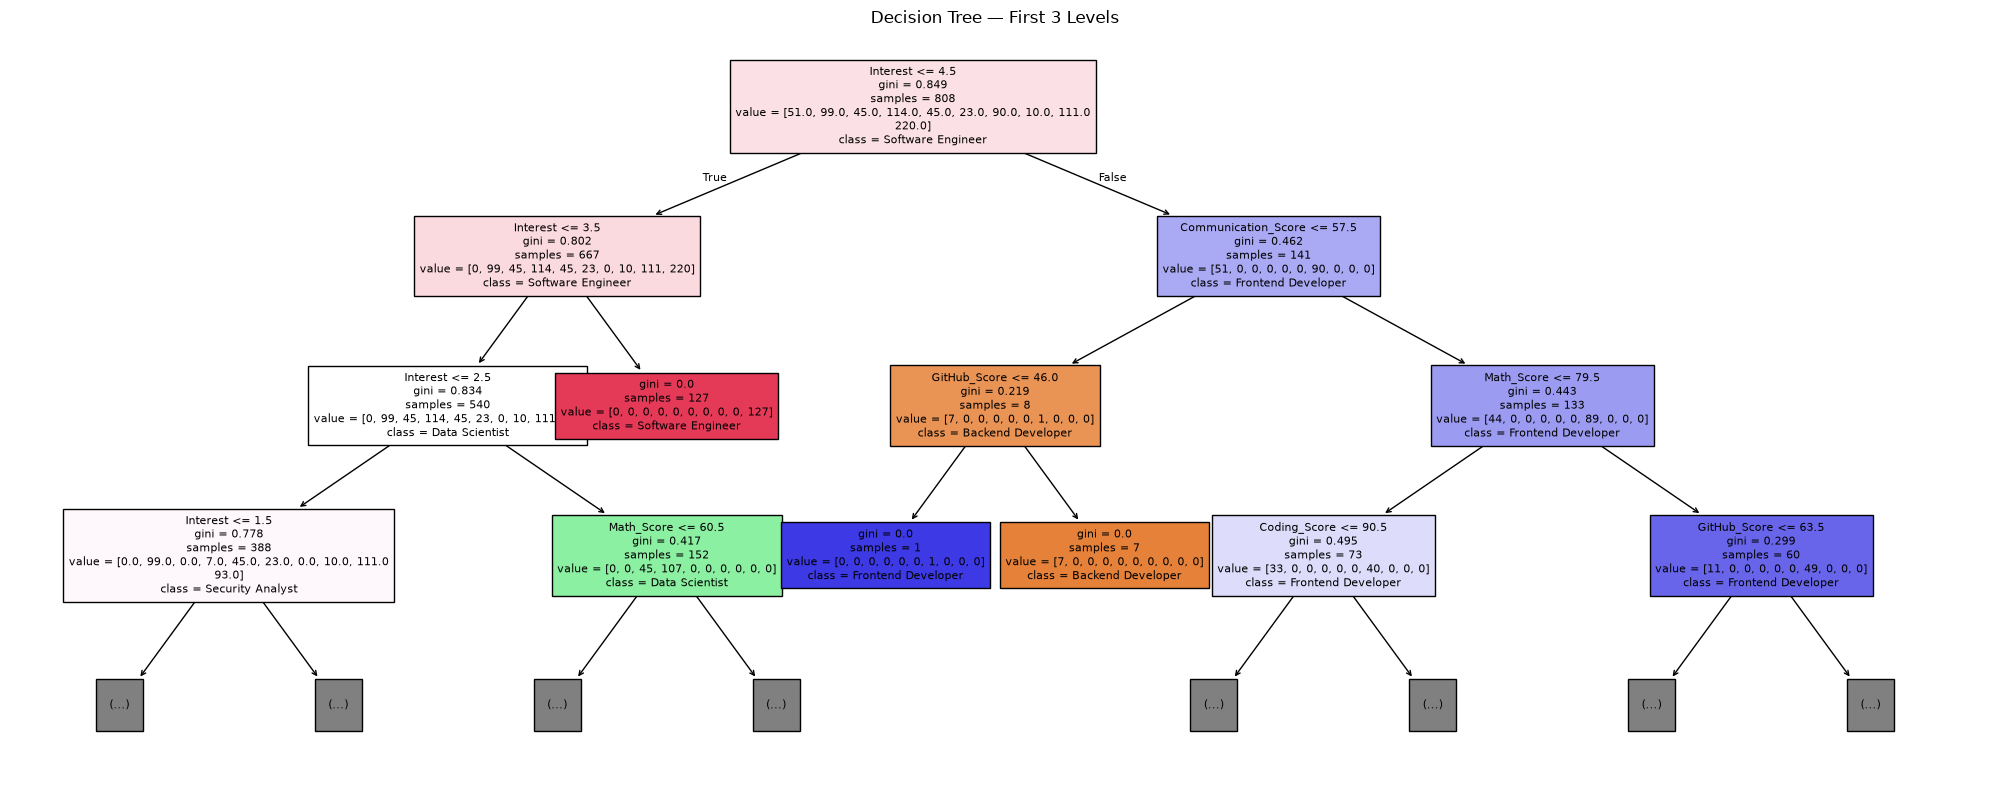

In [8]:
# ══════════════════════════════════════════════════════════════
# STEP 3 — Decision Tree
# ══════════════════════════════════════════════════════════════
print("\n──── Decision Tree ────")
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_acc   = accuracy_score(y_test, dt_preds)
dt_cv    = cross_val_score(dt, X, y, cv=5, scoring="accuracy").mean()
print(f"Decision Tree — Test Accuracy : {dt_acc:.4f}")
print(f"Decision Tree — 5-Fold CV Avg : {dt_cv:.4f}")
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, dt_preds, target_names=label_encoders["Career"].classes_))

# Save Decision Tree rules as text
rules = export_text(dt, feature_names=feature_names)
with open(os.path.join(MODEL_DIR, "decision_tree_rules.txt"), "w") as f:
    f.write(rules)
print("📄 Decision tree rules saved.")

# Visualise tree (first 3 levels)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feature_names, class_names=label_encoders["Career"].classes_,
          filled=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title("Decision Tree — First 3 Levels")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "decision_tree_plot.png"), dpi=100)
plt.show()



In [9]:
# ══════════════════════════════════════════════════════════════
# STEP 4 — Random Forest (with GridSearch)
# ══════════════════════════════════════════════════════════════
print("\n──── Random Forest ────")

# Quick grid search over key hyperparameters
param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5],
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
gs = GridSearchCV(rf_base, param_grid, cv=5, scoring="accuracy", verbose=1)
gs.fit(X_train, y_train)

print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")

rf = gs.best_estimator_
rf_preds = rf.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
print(f"Random Forest — Test Accuracy: {rf_acc:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_preds, target_names=label_encoders["Career"].classes_))




──── Random Forest ────
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV acc : 0.7710
Random Forest — Test Accuracy: 0.7574

Classification Report (Random Forest):
                           precision    recall  f1-score   support

        Backend Developer       0.25      0.15      0.19        13
           Cloud Engineer       0.71      1.00      0.83        25
             Data Analyst       0.00      0.00      0.00        11
           Data Scientist       0.70      0.93      0.80        28
          DevOps Engineer       0.00      0.00      0.00        11
           Ethical Hacker       1.00      0.17      0.29         6
       Frontend Developer       0.59      0.73      0.65        22
Machine Learning Engineer       0.50      0.33      0.40         3
         Security Analyst       0.80      1.00      0.89        28
        Software Engineer       0.98      0.98      0.98        55


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_c


🏆 Best model: Random Forest (0.7574)


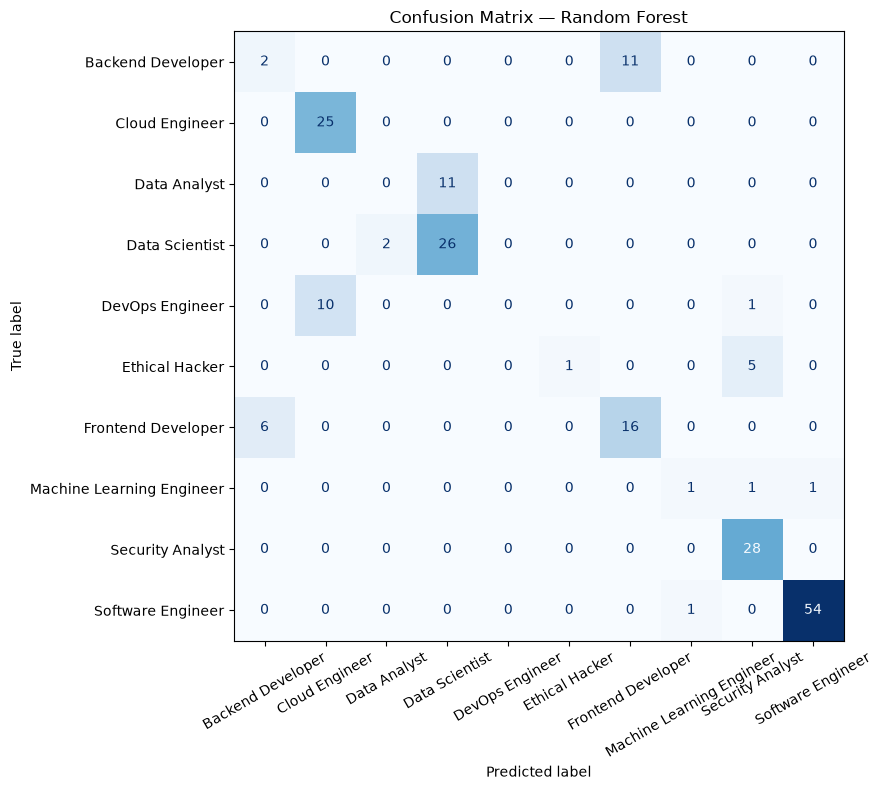

In [10]:
# ══════════════════════════════════════════════════════════════
# STEP 5 — Confusion Matrix for best model
# ══════════════════════════════════════════════════════════════
best_model  = rf if rf_acc >= dt_acc else dt
best_preds  = rf_preds if rf_acc >= dt_acc else dt_preds
best_name   = "Random Forest" if rf_acc >= dt_acc else "Decision Tree"
print(f"\n🏆 Best model: {best_name} ({max(rf_acc, dt_acc):.4f})")

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoders["Career"].classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=100)
plt.show()



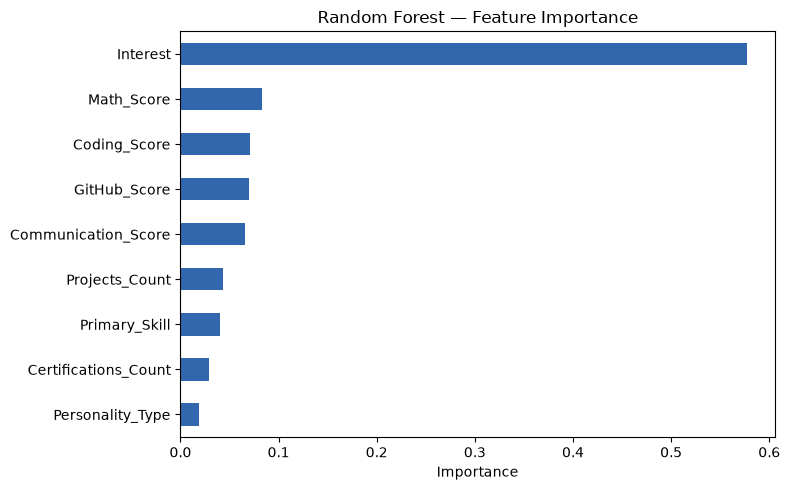

In [11]:
# ══════════════════════════════════════════════════════════════
# STEP 6 — Feature Importance
# ══════════════════════════════════════════════════════════════
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="#3266ad")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "feature_importance.png"), dpi=100)
plt.show()



In [12]:
# ══════════════════════════════════════════════════════════════
# STEP 7 — Save Models
# ══════════════════════════════════════════════════════════════
with open(os.path.join(MODEL_DIR, "decision_tree.pkl"), "wb") as f:
    pickle.dump(dt, f)

with open(os.path.join(MODEL_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf, f)

with open(os.path.join(MODEL_DIR, "best_model.pkl"), "wb") as f:
    pickle.dump(best_model, f)

# Save feature names for Streamlit
with open(os.path.join(MODEL_DIR, "feature_names.pkl"), "wb") as f:
    pickle.dump(feature_names, f)

print(f"\n✅ All models saved to: {MODEL_DIR}")
print("   Files: decision_tree.pkl | random_forest.pkl | best_model.pkl")
print("          label_encoders.pkl | scaler.pkl | feature_names.pkl")


✅ All models saved to: C:\Users\LENOVO\OneDrive\Desktop\Career Mentor\Project File
   Files: decision_tree.pkl | random_forest.pkl | best_model.pkl
          label_encoders.pkl | scaler.pkl | feature_names.pkl
